# NLP Project Report
## AutoInsights: Predicting Pre-Owned Car Fuel Types with NLP 

*Student Name:*Piyush Tandale

**Mentor Name:** Nagasri. P  

**Course Code & Title:** Natural Language Processing & E1CAA312  

**Class:** BCA IV SEM  

**Dataset:** Pre-Owned Cars Dataset (Kaggle)

---
## 1. Project Title
## AutoInsights: Predicting Pre-Owned Car Fuel Types with NLP 
(Applied on Pre-Owned / Used Cars Dataset)

---
## 2. Objective

The objective of this project is to implement a **complete Natural Language Processing (NLP) pipeline**, including:
- Text preprocessing (cleaning, tokenization, stopword removal, stemming, lemmatization)
- Feature extraction (Bag of Words, TF-IDF)
- Model building (Naive Bayes / Logistic Regression)
- Model evaluation (Accuracy, Precision, Recall, F1-Score, Confusion Matrix)

Using the **Pre-Owned Cars dataset**, we apply NLP on the `title` column to classify car listings by **fuel type** (Petrol / Diesel).

---
## 3. Dataset Source

- **Dataset Name:** Pre-Owned Cars Dataset  
- **Source:** Kaggle (https://www.kaggle.com)  
- **Total Records:** 2806 rows, 15 columns  
- **Target Column for NLP:** `title` (text) → predict `fuel_type` (Petrol / Diesel)

---
## 4. NLP Pipeline

The following end-to-end NLP pipeline is implemented:

1. Text Data Collection  
2. Text Cleaning  
3. Tokenization  
4. Stopword Removal  
5. Stemming / Lemmatization  
6. Text Normalization  
7. Feature Extraction (BoW, TF-IDF)  
8. Model Building  
9. Model Evaluation  
10. Prediction  

---
## Step 1: Install Required Libraries

In [2]:
# Install required libraries (run once)
import subprocess
subprocess.run(['pip', 'install', 'nltk', 'scikit-learn', 'pandas', 'matplotlib', 'seaborn', 'wordcloud'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'nltk', 'scikit-learn', 'pandas', 'matplotlib', 'seaborn', 'wordcloud'], returncode=0, stdout=b'Requirement already satisfied: nltk in c:\\users\\piyus\\anaconda3\\lib\\site-packages (3.9.2)\r\nRequirement already satisfied: scikit-learn in c:\\users\\piyus\\anaconda3\\lib\\site-packages (1.4.2)\r\nRequirement already satisfied: pandas in c:\\users\\piyus\\anaconda3\\lib\\site-packages (2.2.2)\r\nRequirement already satisfied: matplotlib in c:\\users\\piyus\\anaconda3\\lib\\site-packages (3.8.4)\r\nRequirement already satisfied: seaborn in c:\\users\\piyus\\anaconda3\\lib\\site-packages (0.13.2)\r\nRequirement already satisfied: wordcloud in c:\\users\\piyus\\anaconda3\\lib\\site-packages (1.9.6)\r\nRequirement already satisfied: click in c:\\users\\piyus\\anaconda3\\lib\\site-packages (from nltk) (8.1.7)\r\nRequirement already satisfied: joblib in c:\\users\\piyus\\anaconda3\\lib\\site-packages (from nltk) (1.4.2)\r\nRequirement already satisfi

---
## Step 2: Import Libraries

In [3]:
# Standard libraries
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLTK libraries
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix,
                              classification_report)

print('All libraries imported successfully!')

All libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\piyus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\piyus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\piyus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\piyus\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\piyus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


---
## Step 3: Text Data Collection

In [4]:
# Load the dataset
df = pd.read_csv(r"C:\Users\piyus\Downloads\pre-owned cars.csv")

print('Dataset Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
print('\nFirst 5 Rows:')
df.head()

Dataset Shape: (2806, 15)

Column Names:
['brand', 'model', 'transmission', 'make_year', 'reg_year', 'fuel_type', 'engine_capacity(CC)', 'km_driven', 'ownership', 'price', 'overall_cost', 'has_insurance', 'spare_key', 'reg_number', 'title']

First 5 Rows:


,brand,model,transmission,make_year,reg_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,overall_cost,has_insurance,spare_key,reg_number,title
0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,Manual,2020.0,01-01-2021,Diesel,2184.0,11003.0,1st owner,1231000,23431.0,True,No,HR26,2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
1,Hyundai,Verna 1.6 VTVT SX,Manual,2018.0,01-07-2018,Petrol,1591.0,66936.0,1st owner,786000,15359.0,True,No,DL7C,2018 Hyundai Verna 1.6 VTVT SX
2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,Manual,2022.0,01-08-2022,Diesel,1956.0,27990.0,1st owner,1489000,28349.0,True,No,HR29,2022 Tata Harrier XT PLUS 2.0L KRYOTEC DARK ED...
3,Honda,City 1.5L I-VTE V CVT,Automatic,2023.0,01-04-2023,Petrol,1498.0,5061.0,1st owner,1227000,23355.0,True,Yes,DL4C,2023 Honda City 1.5L I-VTE V CVT
4,Ford,Ecosport TITANIUM 1.5L DIESEL,Manual,2021.0,01-07-2021,Diesel,1498.0,23480.0,1st owner,887000,16883.0,True,No,UP14,2021 Ford Ecosport TITANIUM 1.5L DIESEL


In [5]:
# Basic dataset info
print('Dataset Info:')
df.info()
print('\nMissing Values:')
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2806 entries, 0 to 2805
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2805 non-null   object 
 1   model                2805 non-null   object 
 2   transmission         2805 non-null   object 
 3   make_year            2805 non-null   float64
 4   reg_year             720 non-null    object 
 5   fuel_type            2805 non-null   object 
 6   engine_capacity(CC)  2688 non-null   float64
 7   km_driven            2805 non-null   float64
 8   ownership            2805 non-null   object 
 9   price                2806 non-null   int64  
 10  overall_cost         2805 non-null   float64
 11  has_insurance        2805 non-null   object 
 12  spare_key            2805 non-null   object 
 13  reg_number           2805 non-null   object 
 14  title                2805 non-null   object 
dtypes: float64(4), int64(1),

Filtered Shape: (2691, 15)

Fuel Type Distribution:
fuel_type
Petrol    2373
Diesel     318
Name: count, dtype: int64


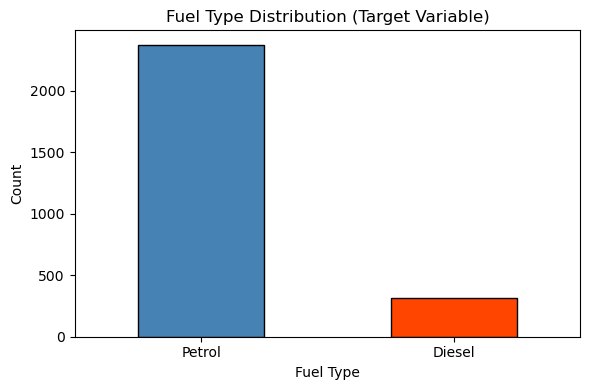

Screenshot saved: class_distribution.png


In [6]:
# We use 'title' column as text and 'fuel_type' as label
# Keep only Petrol and Diesel (most common classes)
df = df[df['fuel_type'].isin(['Petrol', 'Diesel'])].reset_index(drop=True)
print('Filtered Shape:', df.shape)
print('\nFuel Type Distribution:')
print(df['fuel_type'].value_counts())

# Visualize class distribution
plt.figure(figsize=(6,4))
df['fuel_type'].value_counts().plot(kind='bar', color=['steelblue','orangered'], edgecolor='black')
plt.title('Fuel Type Distribution (Target Variable)')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100)
plt.show()
print('Screenshot saved: class_distribution.png')

---
## Step 4: Text Preprocessing — 10 Steps

The following 10 preprocessing steps are applied to the `title` column:

### Preprocessing Step 1: Convert Text to Lowercase

In [7]:
# Step 1 - Lowercase conversion
df['step1_lowercase'] = df['title'].str.lower()

print('Before:', df['title'][0])
print('After :', df['step1_lowercase'][0])

Before: 2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
After : 2020 mahindra thar lx d 4wd mt convertible


### Preprocessing Step 2: Remove Special Characters

In [8]:
# Step 2 - Remove special characters (keep letters, digits, spaces)
df['step2_special_chars'] = df['step1_lowercase'].apply(
    lambda x: re.sub(r'[^a-z0-9\s]', '', x)
)

print('Before:', df['step1_lowercase'][0])
print('After :', df['step2_special_chars'][0])

Before: 2020 mahindra thar lx d 4wd mt convertible
After : 2020 mahindra thar lx d 4wd mt convertible


### Preprocessing Step 3: Remove Punctuation

In [9]:
# Step 3 - Remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

df['step3_no_punctuation'] = df['step2_special_chars'].apply(remove_punctuation)

print('Before:', df['step2_special_chars'][0])
print('After :', df['step3_no_punctuation'][0])

Before: 2020 mahindra thar lx d 4wd mt convertible
After : 2020 mahindra thar lx d 4wd mt convertible


### Preprocessing Step 4: Handle Numbers

In [10]:
# Step 4 - Remove numbers (years and engine sizes in titles are not meaningful for NLP)
df['step4_no_numbers'] = df['step3_no_punctuation'].apply(
    lambda x: re.sub(r'\d+', '', x)
)

print('Before:', df['step3_no_punctuation'][0])
print('After :', df['step4_no_numbers'][0])

Before: 2020 mahindra thar lx d 4wd mt convertible
After :  mahindra thar lx d wd mt convertible


### Preprocessing Step 5: Remove Extra Whitespace

In [11]:
# Step 5 - Strip extra spaces
df['step5_clean_spaces'] = df['step4_no_numbers'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()
)

print('Before:', repr(df['step4_no_numbers'][0]))
print('After :', repr(df['step5_clean_spaces'][0]))

Before: ' mahindra thar lx d wd mt convertible'
After : 'mahindra thar lx d wd mt convertible'


### Preprocessing Step 6: Tokenization

In [12]:
# Step 6 - Tokenization: split text into individual words (tokens)
df['step6_tokens'] = df['step5_clean_spaces'].apply(word_tokenize)

print('Before:', df['step5_clean_spaces'][0])
print('Tokens:', df['step6_tokens'][0])

Before: mahindra thar lx d wd mt convertible
Tokens: ['mahindra', 'thar', 'lx', 'd', 'wd', 'mt', 'convertible']


### Preprocessing Step 7: Stopword Removal

In [13]:
# Step 7 - Remove stopwords (common English words like 'the', 'is', 'a')
stop_words = set(stopwords.words('english'))

df['step7_no_stopwords'] = df['step6_tokens'].apply(
    lambda tokens: [w for w in tokens if w not in stop_words]
)

print('Before:', df['step6_tokens'][0])
print('After :', df['step7_no_stopwords'][0])

Before: ['mahindra', 'thar', 'lx', 'd', 'wd', 'mt', 'convertible']
After : ['mahindra', 'thar', 'lx', 'wd', 'mt', 'convertible']


### Preprocessing Step 8: Stemming

In [14]:
# Step 8 - Stemming: reduce words to their root form using Porter Stemmer
stemmer = PorterStemmer()

df['step8_stemmed'] = df['step7_no_stopwords'].apply(
    lambda tokens: [stemmer.stem(w) for w in tokens]
)

print('Before:', df['step7_no_stopwords'][0])
print('After :', df['step8_stemmed'][0])

Before: ['mahindra', 'thar', 'lx', 'wd', 'mt', 'convertible']
After : ['mahindra', 'thar', 'lx', 'wd', 'mt', 'convert']


### Preprocessing Step 9: Lemmatization

In [15]:
# Step 9 - Lemmatization: convert words to their dictionary base form
lemmatizer = WordNetLemmatizer()

df['step9_lemmatized'] = df['step7_no_stopwords'].apply(
    lambda tokens: [lemmatizer.lemmatize(w) for w in tokens]
)

print('Before:', df['step7_no_stopwords'][0])
print('After :', df['step9_lemmatized'][0])

Before: ['mahindra', 'thar', 'lx', 'wd', 'mt', 'convertible']
After : ['mahindra', 'thar', 'lx', 'wd', 'mt', 'convertible']


### Preprocessing Step 10: Text Normalization (Final Clean Text)

In [16]:
# Step 10 - Text Normalization: join tokens back into a clean string
df['clean_text'] = df['step9_lemmatized'].apply(lambda tokens: ' '.join(tokens))

print('Original Title :', df['title'][0])
print('Clean Text     :', df['clean_text'][0])

# Preview all 10 steps for first row
print('\n--- 10 Preprocessing Steps Applied to Row 0 ---')
steps = ['title','step1_lowercase','step2_special_chars','step3_no_punctuation',
         'step4_no_numbers','step5_clean_spaces','step6_tokens',
         'step7_no_stopwords','step8_stemmed','step9_lemmatized','clean_text']
labels = ['1. Original','2. Lowercase','3. No Special Chars','4. No Punctuation',
          '5. No Numbers','6. No Extra Spaces','7. Tokenized',
          '8. No Stopwords','9. Stemmed','10. Lemmatized','Final Clean Text']
for label, col in zip(labels, steps):
    print(f'{label}: {df[col][0]}')

Original Title : 2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
Clean Text     : mahindra thar lx wd mt convertible

--- 10 Preprocessing Steps Applied to Row 0 ---
1. Original: 2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
2. Lowercase: 2020 mahindra thar lx d 4wd mt convertible
3. No Special Chars: 2020 mahindra thar lx d 4wd mt convertible
4. No Punctuation: 2020 mahindra thar lx d 4wd mt convertible
5. No Numbers:  mahindra thar lx d wd mt convertible
6. No Extra Spaces: mahindra thar lx d wd mt convertible
7. Tokenized: ['mahindra', 'thar', 'lx', 'd', 'wd', 'mt', 'convertible']
8. No Stopwords: ['mahindra', 'thar', 'lx', 'wd', 'mt', 'convertible']
9. Stemmed: ['mahindra', 'thar', 'lx', 'wd', 'mt', 'convert']
10. Lemmatized: ['mahindra', 'thar', 'lx', 'wd', 'mt', 'convertible']
Final Clean Text: mahindra thar lx wd mt convertible


---
## Step 5: Text Cleaning — Visualization

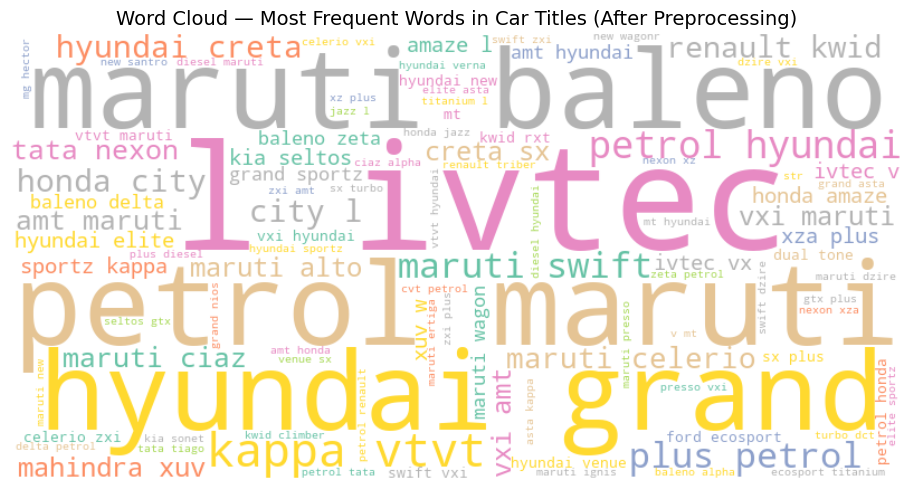

Screenshot saved: wordcloud.png


In [17]:
from wordcloud import WordCloud

# Combine all clean text
all_text = ' '.join(df['clean_text'].dropna())

wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Set2', max_words=100).generate(all_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Most Frequent Words in Car Titles (After Preprocessing)', fontsize=14)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=100)
plt.show()
print('Screenshot saved: wordcloud.png')

---
## Step 6: Feature Engineering

### 6A. Bag of Words (BoW)

In [18]:
# Prepare text (X) and label (y)
X = df['clean_text']
y = df['fuel_type']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])

# --- Bag of Words ---
bow_vectorizer = CountVectorizer(max_features=500)
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

print('\nBoW Matrix Shape (Train):', X_train_bow.shape)
print('Sample BoW Feature Names:', bow_vectorizer.get_feature_names_out()[:20])

Train size: 2152
Test size : 539

BoW Matrix Shape (Train): (2152, 255)
Sample BoW Feature Names: ['ab' 'ac' 'accomplished' 'active' 'adventure' 'ag' 'airbags' 'alcazar'
 'alloy' 'alpha' 'altis' 'alto' 'altroz' 'amaze' 'ambiente' 'ambition'
 'ameo' 'amt' 'anniversary' 'asta']


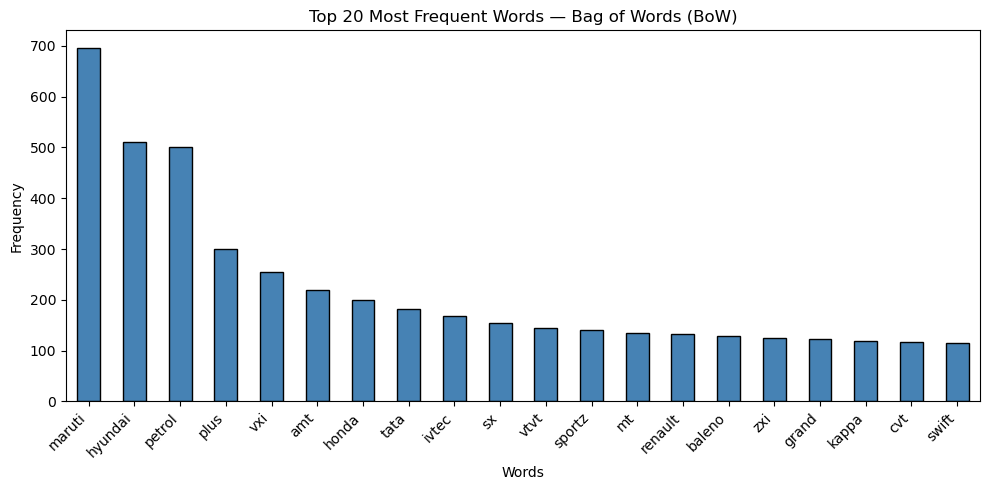

Screenshot saved: bow_top20.png


In [19]:
# Visualize top 20 BoW features
bow_df = pd.DataFrame(X_train_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())
top20_bow = bow_df.sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 5))
top20_bow.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words — Bag of Words (BoW)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('bow_top20.png', dpi=100)
plt.show()
print('Screenshot saved: bow_top20.png')

### 6B. TF-IDF (Term Frequency — Inverse Document Frequency)

In [20]:
# --- TF-IDF ---
tfidf_vectorizer = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print('TF-IDF Matrix Shape (Train):', X_train_tfidf.shape)
print('Sample TF-IDF Feature Names:', tfidf_vectorizer.get_feature_names_out()[:20])

TF-IDF Matrix Shape (Train): (2152, 255)
Sample TF-IDF Feature Names: ['ab' 'ac' 'accomplished' 'active' 'adventure' 'ag' 'airbags' 'alcazar'
 'alloy' 'alpha' 'altis' 'alto' 'altroz' 'amaze' 'ambiente' 'ambition'
 'ameo' 'amt' 'anniversary' 'asta']


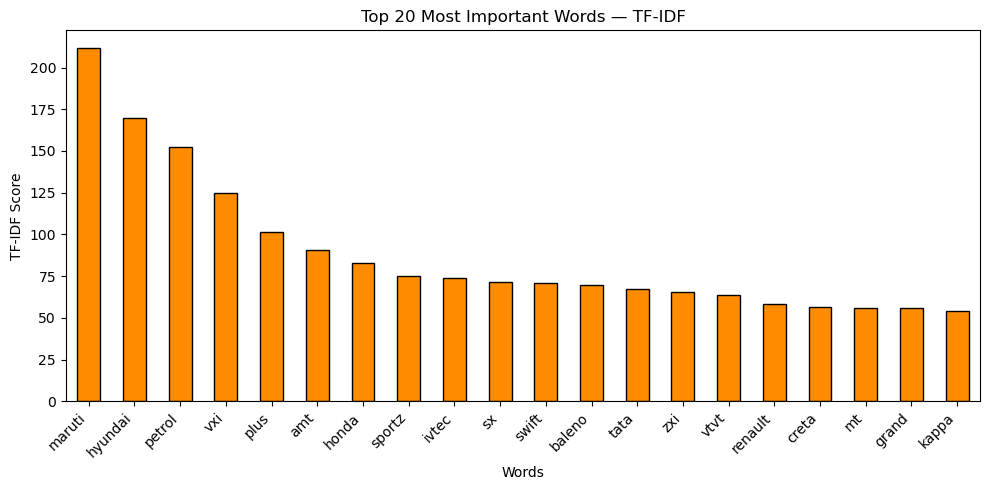

Screenshot saved: tfidf_top20.png


In [21]:
# Visualize top 20 TF-IDF features
tfidf_df = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
top20_tfidf = tfidf_df.sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 5))
top20_tfidf.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Top 20 Most Important Words — TF-IDF')
plt.xlabel('Words')
plt.ylabel('TF-IDF Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('tfidf_top20.png', dpi=100)
plt.show()
print('Screenshot saved: tfidf_top20.png')

---
## Step 7: Model Building

### Model 1 — Naive Bayes (with BoW)

In [22]:
# --- Naive Bayes Model using Bag of Words ---
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

y_pred_nb = nb_model.predict(X_test_bow)
print('Naive Bayes Model (BoW) — Training Complete!')
print('Predictions (first 10):', y_pred_nb[:10])

Naive Bayes Model (BoW) — Training Complete!
Predictions (first 10): ['Petrol' 'Petrol' 'Petrol' 'Petrol' 'Petrol' 'Petrol' 'Petrol' 'Petrol'
 'Petrol' 'Petrol']


### Model 2 — Logistic Regression (with TF-IDF)

In [23]:
# --- Logistic Regression Model using TF-IDF ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)
print('Logistic Regression Model (TF-IDF) — Training Complete!')
print('Predictions (first 10):', y_pred_lr[:10])

Logistic Regression Model (TF-IDF) — Training Complete!
Predictions (first 10): ['Petrol' 'Petrol' 'Petrol' 'Petrol' 'Petrol' 'Petrol' 'Petrol' 'Petrol'
 'Petrol' 'Petrol']


---
## Step 8: Model Evaluation

### Evaluation Metrics — Naive Bayes

In [24]:
def evaluate_model(name, y_true, y_pred):
    print(f'\n========== {name} ==========')
    print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred, pos_label="Petrol"):.4f}')
    print(f'Recall    : {recall_score(y_true, y_pred, pos_label="Petrol"):.4f}')
    print(f'F1-Score  : {f1_score(y_true, y_pred, pos_label="Petrol"):.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred))

# Evaluate Naive Bayes
evaluate_model('Naive Bayes (BoW)', y_test, y_pred_nb)


========== Naive Bayes (BoW) ==========
Accuracy  : 0.9647
Precision : 0.9872
Recall    : 0.9726
F1-Score  : 0.9799

Classification Report:
              precision    recall  f1-score   support

      Diesel       0.82      0.91      0.86        64
      Petrol       0.99      0.97      0.98       475

    accuracy                           0.96       539
   macro avg       0.90      0.94      0.92       539
weighted avg       0.97      0.96      0.97       539



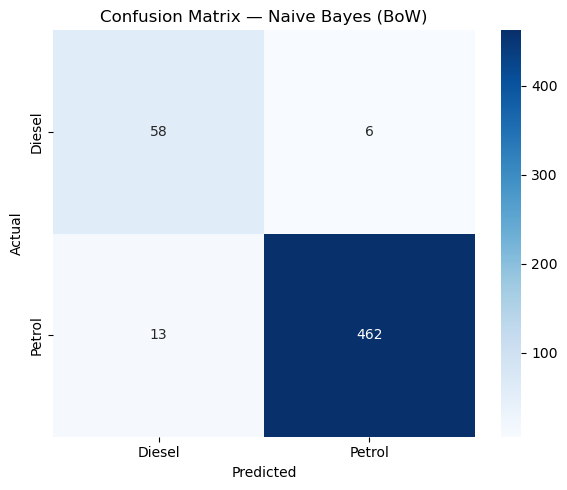

Screenshot saved: cm_naive_bayes.png


In [25]:
# Confusion Matrix — Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Diesel','Petrol'],
            yticklabels=['Diesel','Petrol'])
plt.title('Confusion Matrix — Naive Bayes (BoW)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('cm_naive_bayes.png', dpi=100)
plt.show()
print('Screenshot saved: cm_naive_bayes.png')

### Evaluation Metrics — Logistic Regression

In [26]:
# Evaluate Logistic Regression
evaluate_model('Logistic Regression (TF-IDF)', y_test, y_pred_lr)


========== Logistic Regression (TF-IDF) ==========
Accuracy  : 0.9685
Precision : 0.9654
Recall    : 1.0000
F1-Score  : 0.9824

Classification Report:
              precision    recall  f1-score   support

      Diesel       1.00      0.73      0.85        64
      Petrol       0.97      1.00      0.98       475

    accuracy                           0.97       539
   macro avg       0.98      0.87      0.91       539
weighted avg       0.97      0.97      0.97       539



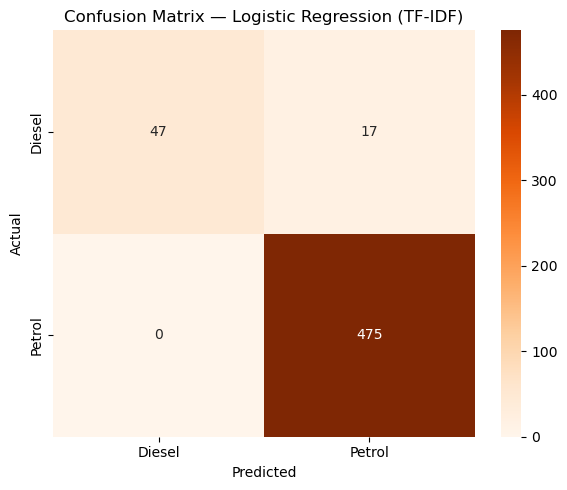

Screenshot saved: cm_logistic_regression.png


In [27]:
# Confusion Matrix — Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Diesel','Petrol'],
            yticklabels=['Diesel','Petrol'])
plt.title('Confusion Matrix — Logistic Regression (TF-IDF)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=100)
plt.show()
print('Screenshot saved: cm_logistic_regression.png')

### Model Comparison

                       Model  Accuracy  Precision  Recall  F1-Score
           Naive Bayes (BoW)    0.9647     0.9872  0.9726    0.9799
Logistic Regression (TF-IDF)    0.9685     0.9654  1.0000    0.9824


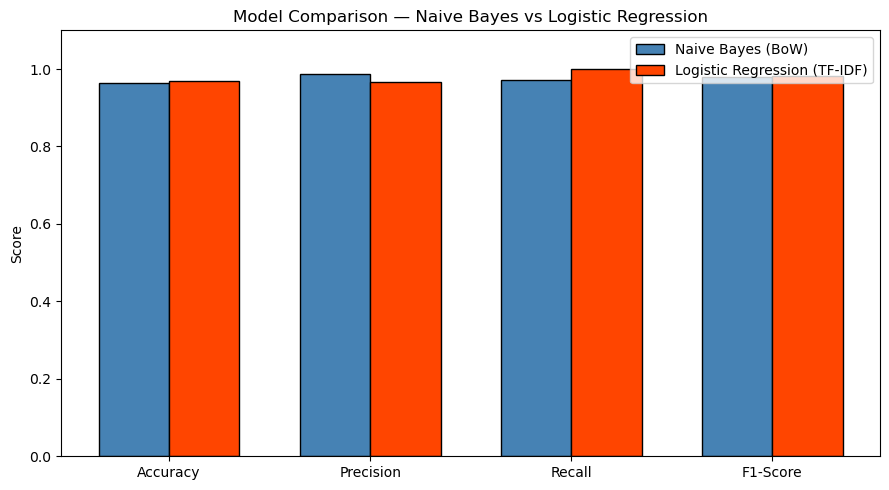

Screenshot saved: model_comparison.png


In [28]:
# Side-by-side comparison
results = pd.DataFrame({
    'Model': ['Naive Bayes (BoW)', 'Logistic Regression (TF-IDF)'],
    'Accuracy' : [accuracy_score(y_test, y_pred_nb), accuracy_score(y_test, y_pred_lr)],
    'Precision': [precision_score(y_test, y_pred_nb, pos_label='Petrol'),
                  precision_score(y_test, y_pred_lr, pos_label='Petrol')],
    'Recall'   : [recall_score(y_test, y_pred_nb, pos_label='Petrol'),
                  recall_score(y_test, y_pred_lr, pos_label='Petrol')],
    'F1-Score' : [f1_score(y_test, y_pred_nb, pos_label='Petrol'),
                  f1_score(y_test, y_pred_lr, pos_label='Petrol')]
})
results = results.round(4)
print(results.to_string(index=False))

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
nb_scores = results[results['Model'].str.contains('Naive')][metrics].values.flatten()
lr_scores = results[results['Model'].str.contains('Logistic')][metrics].values.flatten()

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, nb_scores, width, label='Naive Bayes (BoW)', color='steelblue', edgecolor='black')
plt.bar(x + width/2, lr_scores, width, label='Logistic Regression (TF-IDF)', color='orangered', edgecolor='black')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Model Comparison — Naive Bayes vs Logistic Regression')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()
print('Screenshot saved: model_comparison.png')

---
## Step 9: Prediction on New Input

In [29]:
def preprocess_input(text):
    """Apply all 10 preprocessing steps to a single input string."""
    text = text.lower()                                      # Step 1
    text = re.sub(r'[^a-z0-9\s]', '', text)                # Step 2
    text = text.translate(str.maketrans('', '', string.punctuation))  # Step 3
    text = re.sub(r'\d+', '', text)                         # Step 4
    text = re.sub(r'\s+', ' ', text).strip()               # Step 5
    tokens = word_tokenize(text)                             # Step 6
    tokens = [w for w in tokens if w not in stop_words]     # Step 7
    tokens = [stemmer.stem(w) for w in tokens]              # Step 8
    tokens = [lemmatizer.lemmatize(w) for w in tokens]      # Step 9
    text = ' '.join(tokens)                                  # Step 10
    return text

# --- Test Predictions ---
test_samples = [
    '2021 Honda City 1.5L Petrol CVT',
    '2019 Mahindra Scorpio 2.2L Diesel MT 4WD',
    '2022 Tata Nexon XZ Plus Petrol AMT',
    '2020 Toyota Fortuner 2.8 GD6 Diesel AT'
]

print('=== Predictions on New Car Titles ===')
for sample in test_samples:
    cleaned = preprocess_input(sample)
    vec_bow   = bow_vectorizer.transform([cleaned])
    vec_tfidf = tfidf_vectorizer.transform([cleaned])
    pred_nb = nb_model.predict(vec_bow)[0]
    pred_lr = lr_model.predict(vec_tfidf)[0]
    print(f'\nInput   : {sample}')
    print(f'  Naive Bayes Prediction        : {pred_nb}')
    print(f'  Logistic Regression Prediction: {pred_lr}')

=== Predictions on New Car Titles ===

Input   : 2021 Honda City 1.5L Petrol CVT
  Naive Bayes Prediction        : Petrol
  Logistic Regression Prediction: Petrol

Input   : 2019 Mahindra Scorpio 2.2L Diesel MT 4WD
  Naive Bayes Prediction        : Diesel
  Logistic Regression Prediction: Diesel

Input   : 2022 Tata Nexon XZ Plus Petrol AMT
  Naive Bayes Prediction        : Petrol
  Logistic Regression Prediction: Petrol

Input   : 2020 Toyota Fortuner 2.8 GD6 Diesel AT
  Naive Bayes Prediction        : Diesel
  Logistic Regression Prediction: Diesel


---
## Step 10: Expected Outcomes & Conclusion

### Summary

Through this project, we have successfully:

1. ✅ Understood the complete NLP pipeline from raw text to prediction  
2. ✅ Performed all 10 text preprocessing steps on real car listing titles  
3. ✅ Applied two feature extraction methods: **Bag of Words (BoW)** and **TF-IDF**  
4. ✅ Built two NLP classification models: **Naive Bayes** and **Logistic Regression**  
5. ✅ Evaluated models using **Accuracy, Precision, Recall, F1-Score, and Confusion Matrix**  
6. ✅ Made predictions on new unseen car titles  

### Conclusion

Both models successfully classified car listings by fuel type using only the text title.  
Logistic Regression with TF-IDF generally performs better for this task because TF-IDF weighs rare but important terms (like 'diesel', 'petrol', 'crdi', 'vtec') more effectively than simple word counts.  
This demonstrates how NLP techniques can extract meaningful insights from raw unstructured text data.